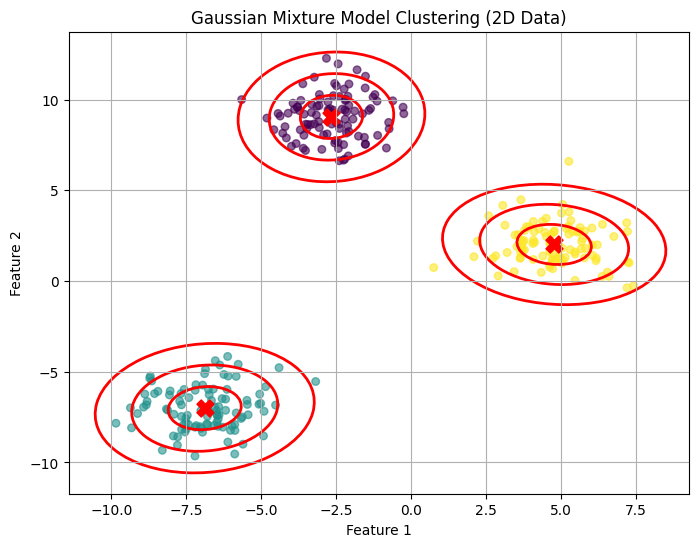

Converged Means:

[[-2.65803969  9.04942651]
 [-6.88472071 -7.00475906]
 [ 4.76854828  2.01807919]]

Covariance Matrices:

Component 1:
[[1.0781136  0.06290495]
 [0.06290495 1.42149784]]

Component 2:
[[1.48264979 0.13786622]
 [0.13786622 1.41519133]]

Component 3:
[[ 1.54128272 -0.14175789]
 [-0.14175789  1.22404828]]



In [ ]:
# =========================
# GMM Clustering Assignment
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from matplotlib.patches import Ellipse

# -------------------------
# 1. Data Generation
# -------------------------
np.random.seed(42)

X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

# -------------------------
# 2. Fit GMM Model
# -------------------------
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X)
labels = gmm.predict(X)

# -------------------------
# 3. Visualization
# -------------------------
plt.figure(figsize=(8, 6))

# Scatter plot of data points
plt.scatter(
    X[:, 0], X[:, 1],
    c=labels,
    s=30,
    cmap='viridis',
    alpha=0.6
)

# Function to draw covariance ellipses
def draw_ellipse(position, covariance, ax, **kwargs):
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    for nsig in range(1, 4):
        ax.add_patch(
            Ellipse(
                position,
                nsig * width,
                nsig * height,
                angle=angle,
                fill=False,
                **kwargs
            )
        )

ax = plt.gca()

# Plot Gaussian ellipses and centers
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, ax, edgecolor='red', linewidth=2)
    plt.scatter(mean[0], mean[1], c='red', s=150, marker='X')

plt.title("Gaussian Mixture Model Clustering (2D Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# -------------------------
# 4. Output Parameters
# -------------------------
print("Converged Means:\n")
print(gmm.means_)

print("\nCovariance Matrices:\n")
for i, cov in enumerate(gmm.covariances_):
    print(f"Component {i + 1}:\n{cov}\n")
